<a href="https://colab.research.google.com/github/sohaibasim46/Final-Year-Project-Sohaib/blob/main/movie_reviews_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Analysis and Topic Modeling of E-Commerce Customer Feedback**

# **Part 1: Importing Files**

In [ ]:
import os
import tarfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Style configuration for plots
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## **Data Acquisition and Extraction**

In [ ]:
# URL and file paths
dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
file_name = "aclImdb_v1.tar.gz"
extracted_folder = "aclImdb"

def download_and_extract(url, save_path, extract_path):
    # Download
    if not os.path.exists(save_path):
        print(f"Downloading {save_path}...")
        response = requests.get(url, stream=True)
        with open(save_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    f.write(chunk)
        print("Download complete.")
    else:
        print("File already exists. Skipping download.")

    # Extract
    if not os.path.exists(extract_path):
        print(f"Extracting {save_path}...")
        with tarfile.open(save_path, "r:gz") as tar:
            tar.extractall()
        print("Extraction complete.")
    else:
        print("Extracted folder already exists.")

download_and_extract(dataset_url, file_name, extracted_folder)

Download complete.
Extracting aclImdb_v1.tar.gz...


/tmp/ipykernel_1766/3229853461.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extraction complete.


## **Data Loading**

In [ ]:
def load_imdb_data(base_path):
    data = []
    # The dataset is split into train and test folders
    for split in ['train', 'test']:
        for sentiment in ['pos', 'neg']:
            path = os.path.join(base_path, split, sentiment)
            if not os.path.exists(path):
                print(f"Warning: Path {path} does not exist.")
                continue

            print(f"Loading {split} - {sentiment}...")
            for file_name in os.listdir(path):
                if file_name.endswith('.txt'):
                    file_path = os.path.join(path, file_name)
                    with open(file_path, 'r', encoding='utf-8') as f:
                        review = f.read()
                        # Filenames are like "ID_Rating.txt"
                        rating = int(file_name.split('_')[1].split('.')[0])
                        data.append({
                            'review': review,
                            'sentiment': sentiment,
                            'split': split,
                            'rating': rating
                        })
    return pd.DataFrame(data)

# Load the data (This may take a minute)
df = load_imdb_data(extracted_folder)

# Convert sentiment to binary label (optional but good for ML later)
df['label'] = df['sentiment'].apply(lambda x: 1 if x == 'pos' else 0)

print(f"Data loaded. Shape: {df.shape}")
df.head()

Loading train - pos...
Loading train - neg...
Loading test - pos...
Loading test - neg...
Data loaded. Shape: (50000, 5)


,review,sentiment,split,rating,label
0,"Of all the movies I have seen, and that's most...",pos,train,9,1
1,"My father, Dr. Gordon Warner (ret. Major, US M...",pos,train,10,1
2,Spoiler This is a great film about a conure. H...,pos,train,9,1
3,Loved the movie. Loved the two families crossi...,pos,train,9,1
4,The Last Hunt is the forgotten Hollywood class...,pos,train,10,1


# **Exploratory Data Analysis & Cleaning**

## **Basic Inspection**

In [ ]:
print("--- Dataset Info ---")
print(df.info())

print("\n--- Class Distribution ---")
print(df['sentiment'].value_counts())

print("\n--- Split Distribution ---")
print(df['split'].value_counts())

# Check for duplicates
duplicates = df.duplicated(subset=['review']).sum()
print(f"\nNumber of duplicate reviews: {duplicates}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
 2   split      50000 non-null  object
 3   rating     50000 non-null  int64 
 4   label      50000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.9+ MB
None

--- Class Distribution ---
sentiment
pos    25000
neg    25000
Name: count, dtype: int64

--- Split Distribution ---
split
train    25000
test     25000
Name: count, dtype: int64

Number of duplicate reviews: 418


## **Text Preprocessing for EDA**

In [ ]:
def clean_text(text):
    # Remove HTML tags (e.g., <br />)
    text = re.sub(r'<br\s*/?>', ' ', text)
    # Remove non-alphabetic characters (optional, depending on depth of EDA)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Cleaning reviews...")
df['clean_review'] = df['review'].apply(clean_text)
df.head()

Cleaning reviews...


,review,sentiment,split,rating,label,clean_review
0,"Of all the movies I have seen, and that's most...",pos,train,9,1,of all the movies i have seen and thats most o...
1,"My father, Dr. Gordon Warner (ret. Major, US M...",pos,train,10,1,my father dr gordon warner ret major us marine...
2,Spoiler This is a great film about a conure. H...,pos,train,9,1,spoiler this is a great film about a conure he...
3,Loved the movie. Loved the two families crossi...,pos,train,9,1,loved the movie loved the two families crossin...
4,The Last Hunt is the forgotten Hollywood class...,pos,train,10,1,the last hunt is the forgotten hollywood class...


## **Feature Engineering**

In [ ]:
# Word count
df['word_count'] = df['clean_review'].apply(lambda x: len(x.split()))

# Character count
df['char_count'] = df['clean_review'].apply(len)

# Average word length
df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)

print("Meta-features created.")
df[['sentiment', 'word_count', 'char_count', 'avg_word_len']].describe()

Meta-features created.


,word_count,char_count,avg_word_len
count,50000.000000,50000.000000,50000.000000
mean,226.852700,1241.017740,5.403371
std,168.178261,939.145489,0.321123
min,4.000000,30.000000,3.800000
25%,124.000000,664.000000,5.191176
50%,170.000000,920.000000,5.391140
75%,275.000000,1504.000000,5.600000
max,2450.000000,13271.000000,13.723404


## **Visualization - Review Length Distribution**

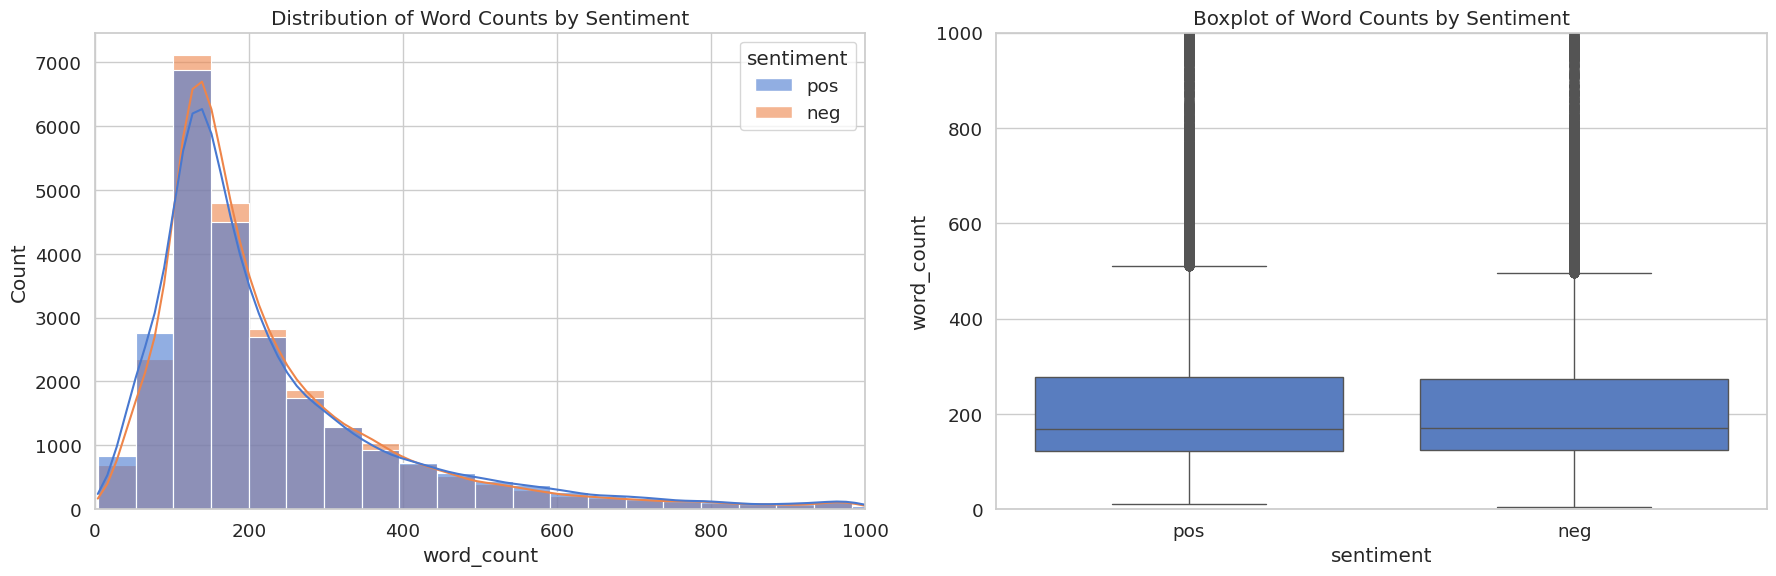

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histogram of Word Counts
sns.histplot(data=df, x='word_count', hue='sentiment', kde=True, bins=50, ax=axes[0], alpha=0.6)
axes[0].set_title('Distribution of Word Counts by Sentiment')
axes[0].set_xlim(0, 1000)  # Limit x-axis to focus on the bulk of data

# Boxplot for Word Counts
sns.boxplot(data=df, x='sentiment', y='word_count', ax=axes[1])
axes[1].set_title('Boxplot of Word Counts by Sentiment')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.show()

## **N-gram Analysis**

/tmp/ipykernel_1766/2418286019.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(y_pos), y=list(x_pos), ax=axes[0], palette='Greens_r')
/tmp/ipykernel_1766/2418286019.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(y_neg), y=list(x_neg), ax=axes[1], palette='Reds_r')


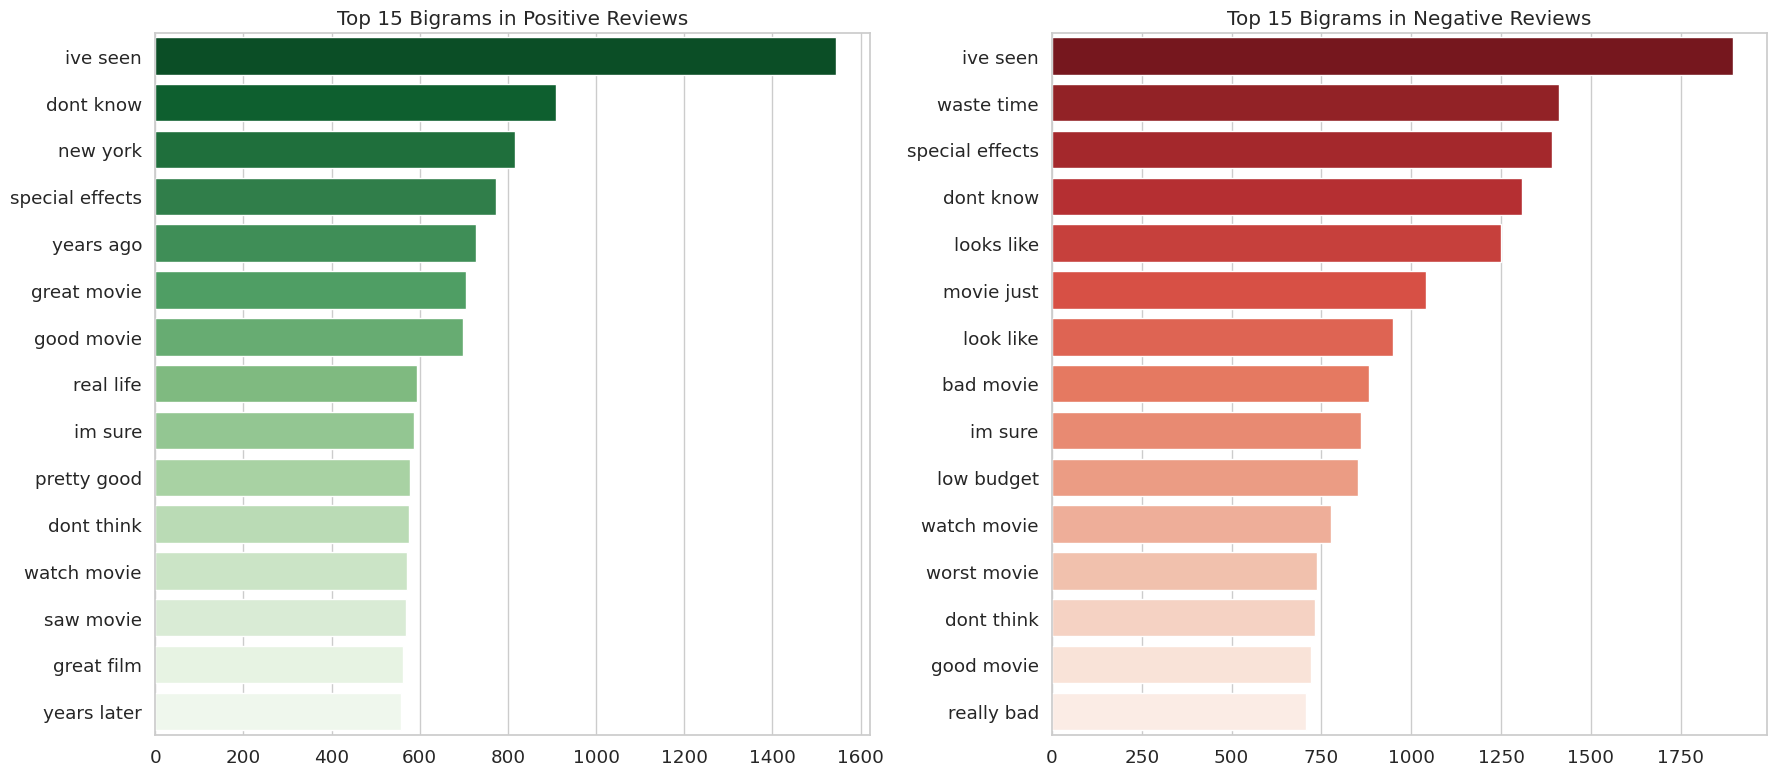

In [ ]:
def get_top_ngrams(corpus, n=1, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Separate corpora
pos_text = df[df['sentiment'] == 'pos']['clean_review']
neg_text = df[df['sentiment'] == 'neg']['clean_review']

# Get top bigrams (2-word phrases)
top_bigrams_pos = get_top_ngrams(pos_text, n=2, top_k=15)
top_bigrams_neg = get_top_ngrams(neg_text, n=2, top_k=15)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Positive Bigrams
x_pos, y_pos = zip(*top_bigrams_pos)
sns.barplot(x=list(y_pos), y=list(x_pos), ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 15 Bigrams in Positive Reviews')

# Negative Bigrams
x_neg, y_neg = zip(*top_bigrams_neg)
sns.barplot(x=list(y_neg), y=list(x_neg), ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 15 Bigrams in Negative Reviews')

plt.tight_layout()
plt.show()

## **Word Clouds**

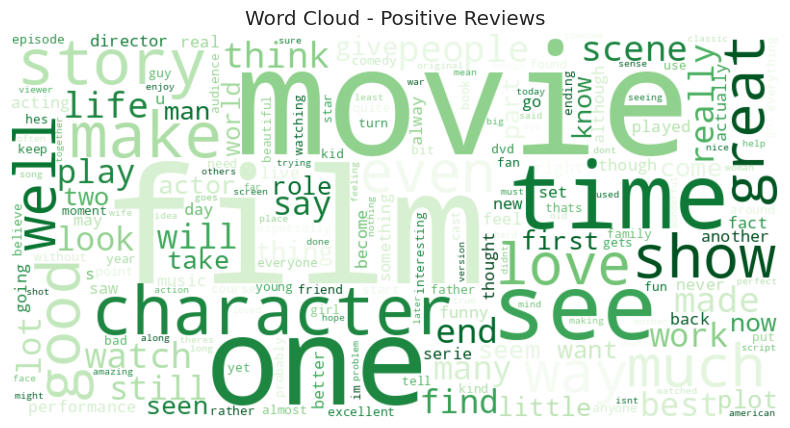

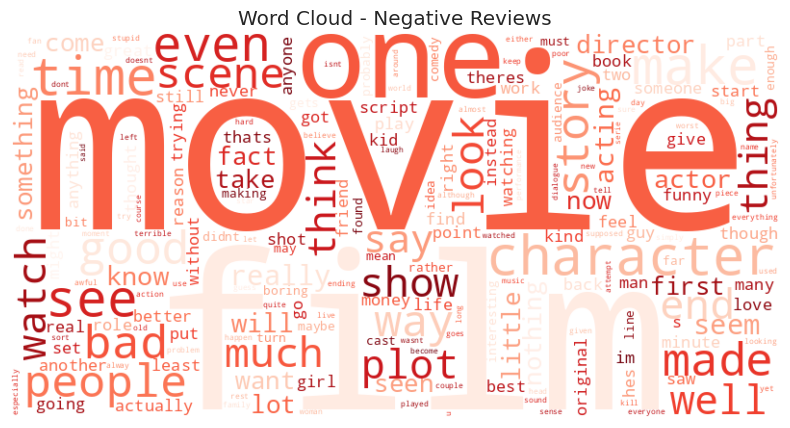

In [ ]:
def plot_wordcloud(text, title, cmap='viridis'):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Positive Word Cloud
plot_wordcloud(pos_text, "Word Cloud - Positive Reviews", cmap='Greens')

# Negative Word Cloud
plot_wordcloud(neg_text, "Word Cloud - Negative Reviews", cmap='Reds')

## **Rating vs Sentiment Check (Sanity Check)**

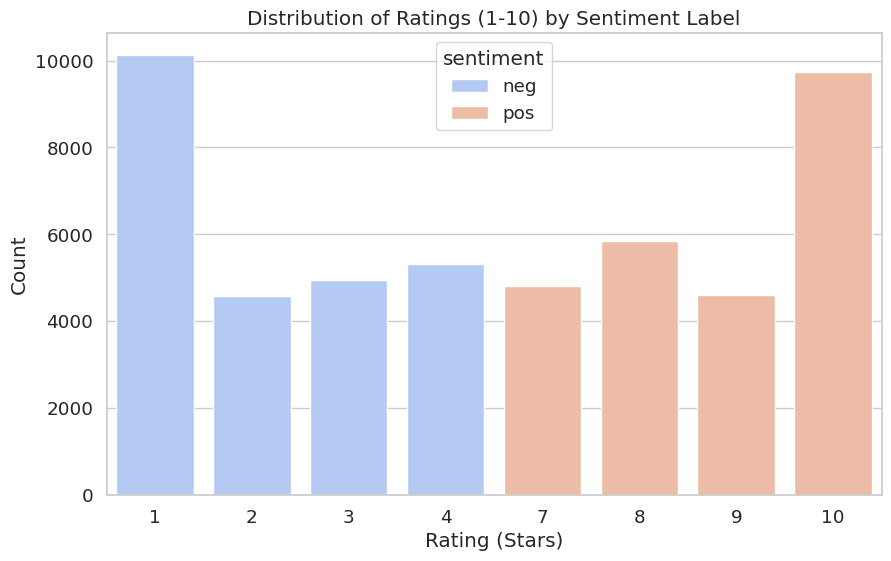

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', hue='sentiment', palette='coolwarm')
plt.title('Distribution of Ratings (1-10) by Sentiment Label')
plt.xlabel('Rating (Stars)')
plt.ylabel('Count')
plt.show()

# Insight:
# Ratings 1-4 should be purely Negative.
# Ratings 7-10 should be purely Positive.
# Ratings 5-6 are usually excluded in this dataset (neutral).

# **Model Training**

## **Data Preparation**

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)

# 1. Prepare Data
# Using 'clean_review' for text and 'label' for target (adjust column names if needed)
X = df['clean_review'].astype(str)
y = df['label'].apply(lambda x: 1 if x == 'pos' else 0) # Encoding: pos=1, neg=0

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# **Tf-IDF Vectorization**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Clean data: Ensure no NaN values in reviews
df['clean_review'] = df['clean_review'].fillna('')

# 2. Robust Label Encoding
le = LabelEncoder()
y = le.fit_transform(df['label'])

# Check to ensure we have two classes now
print(f"Classes found: {le.classes_}")
if len(le.classes_) < 2:
    raise ValueError("The 'label' column still only has one unique value. Please check your data.")

X_train, X_test, y_train, y_test = train_test_split(df['clean_review'], y, test_size=0.2, random_state=42)

# 3. Vectorization
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Classes found: [0 1]


## **Training ML Model**

In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define the remaining traditional ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial NB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

results = []
plot_data = {}

for name, model in models.items():
    # Timing and Training
    start_train = time.time()
    model.fit(X_train_tfidf, y_train)
    train_time = time.time() - start_train

    # Inference
    start_test = time.time()
    y_pred = model.predict(X_test_tfidf)

    # Check for probability support (used for ROC/Precision-Recall curves later)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_proba = y_pred

    test_time = time.time() - start_test

    # Store Metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

    plot_data[name] = {"y_proba": y_proba, "y_pred": y_pred}

## **Model Evaluations**


### SUMMARIZED EVALUATION MATRIX ###
              Model  Accuracy  Precision   Recall  F1-Score  Train Time (s)  Test Time (s)
Logistic Regression    0.8931   0.884304 0.907221  0.895616          0.7680         0.0078
     Multinomial NB    0.8547   0.854388 0.858952  0.856664          0.0521         0.0229
      Random Forest    0.8486   0.855308 0.843126  0.849173        185.0657         1.4610


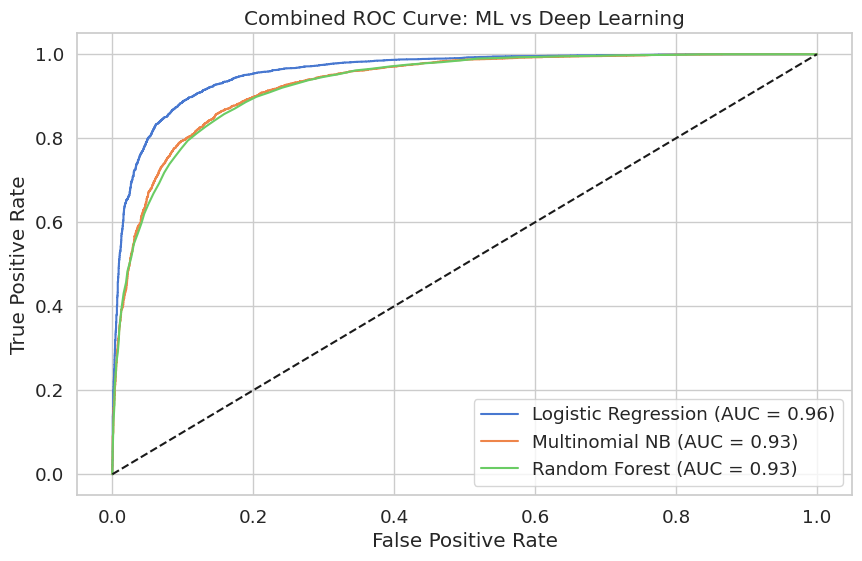


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4945
           1       0.88      0.91      0.90      5055

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


--- Multinomial NB Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4945
           1       0.85      0.86      0.86      5055

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      4945
           1       0.86      0.84      0.85      5055

    accuracy                           0

In [ ]:
# 1. Summarized Evaluation Matrix
eval_matrix = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n### SUMMARIZED EVALUATION MATRIX ###")
print(eval_matrix.to_string(index=False))

# 2. Combined ROC Curve
plt.figure(figsize=(10, 6))
for name, data in plot_data.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Combined ROC Curve: ML vs Deep Learning')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 3. Detailed Classification Reports
for name, data in plot_data.items():
    print(f"\n--- {name} Classification Report ---")
    print(classification_report(y_test, data['y_pred']))

## **Visualization**

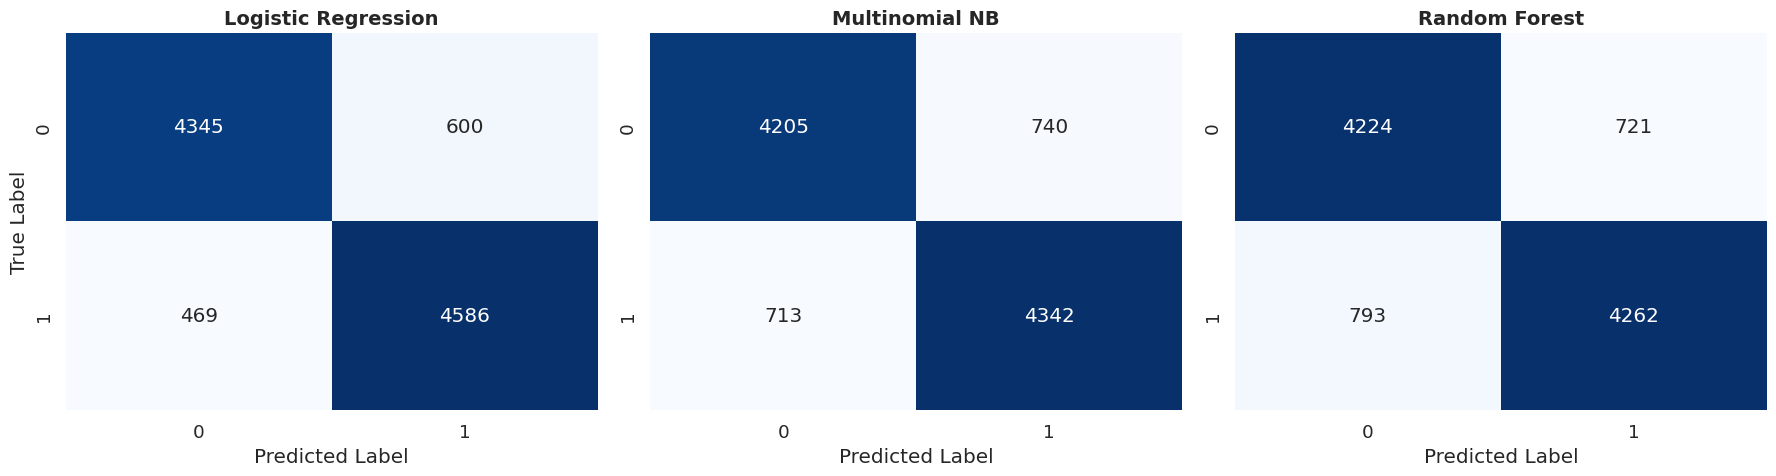

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a 1x3 grid for the 3 remaining models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# Get available models from plot_data (now contains 3 models)
all_models = list(plot_data.items())

for i, (name, data) in enumerate(all_models):
    # Calculate confusion matrix
    cm = confusion_matrix(y_test, data['y_pred'])

    # Plotting using a professional color palette
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False) # Hide colorbar for a cleaner look

    axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    if i == 0:
        axes[i].set_ylabel('True Label')
    else:
        axes[i].set_ylabel('') # Only show Y-axis label on the first plot to save space

# Hide any unused subplots (if your plot_data happens to have fewer than 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# **Hyperparameter Optimization**

In [ ]:
!pip install gensim
from gensim.models import Word2Vec
import numpy as np

# Word2Vec requires a list of tokenized sentences
# Example: [['this', 'is', 'a', 'sentence'], ['another', 'one', 'here']]
X_train_tokens = [text.split() for text in X_train]
X_test_tokens = [text.split() for text in X_test]

# Train the Word2Vec model
w2v_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4)

def get_average_word2vec(tokens, model, vector_size):
    # Filter words that are actually in the model's vocabulary
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# Vectorize the training and testing sets
X_train_w2v = np.array([get_average_word2vec(tokens, w2v_model, 100) for tokens in X_train_tokens])
X_test_w2v = np.array([get_average_word2vec(tokens, w2v_model, 100) for tokens in X_test_tokens])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 29.6 MB/s eta 0:00:00


In [ ]:
from sklearn.naive_bayes import GaussianNB # NB variant that handles negative values
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Update model list for W2V compatibility
w2v_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Gaussian NB": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

w2v_results = []

for name, model in w2v_models.items():
    # Training
    start_train = time.time()
    model.fit(X_train_w2v, y_train)
    train_time = time.time() - start_train

    # Prediction
    start_test = time.time()
    y_pred = model.predict(X_test_w2v)
    test_time = time.time() - start_test

    # Complete Evaluation Metrics
    w2v_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average='weighted', zero_division=0),
        "Train Time (s)": round(train_time, 4),
        "Inference Time (s)": round(test_time, 4)
    })

# Display Results
import pandas as pd
results_df = pd.DataFrame(w2v_results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)  \
0  Logistic Regression    0.8508   0.851015  0.8508  0.850750          0.9573   
1          Gaussian NB    0.6931   0.694432  0.6931  0.692799          0.0486   
2        Random Forest    0.8110   0.811124  0.8110  0.810949         80.2674   

   Inference Time (s)  
0              0.0089  
1              0.0141  
2              0.2389  


## **Visualization After Hyperparameter Optimization**

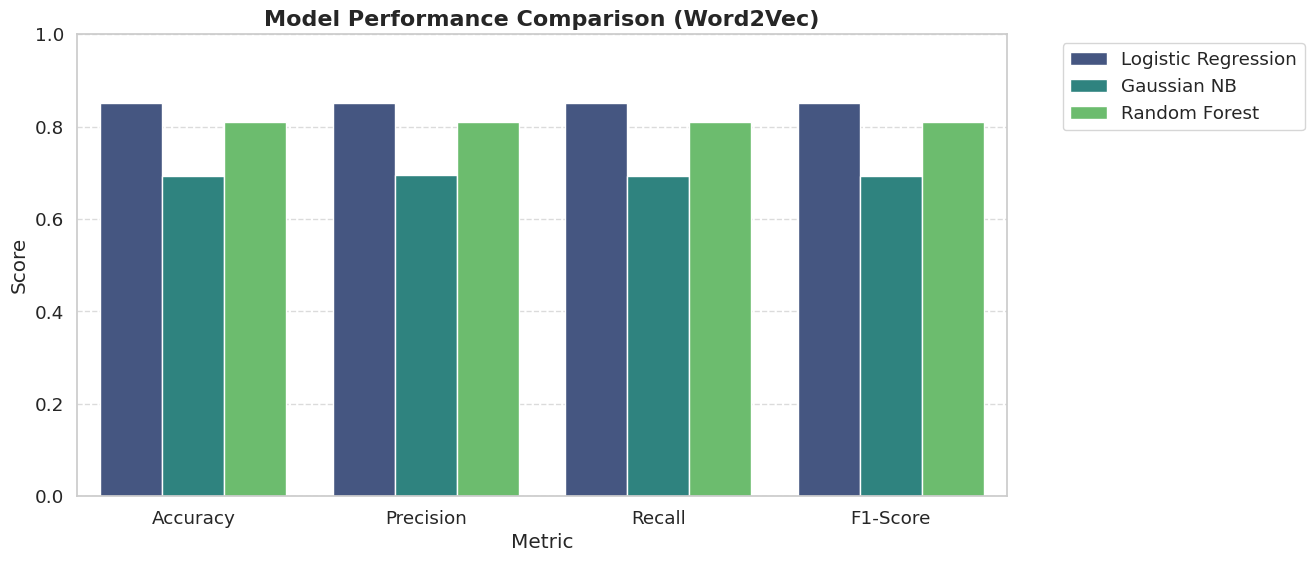

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results_df = pd.DataFrame(w2v_results)

df_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
df_metrics = df_melted[df_melted['Metric'].isin(['Accuracy', 'Precision', 'Recall', 'F1-Score'])]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_metrics, x="Metric", y="Score", hue="Model", palette="viridis")

plt.title("Model Performance Comparison (Word2Vec)", fontsize=16, fontweight='bold')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

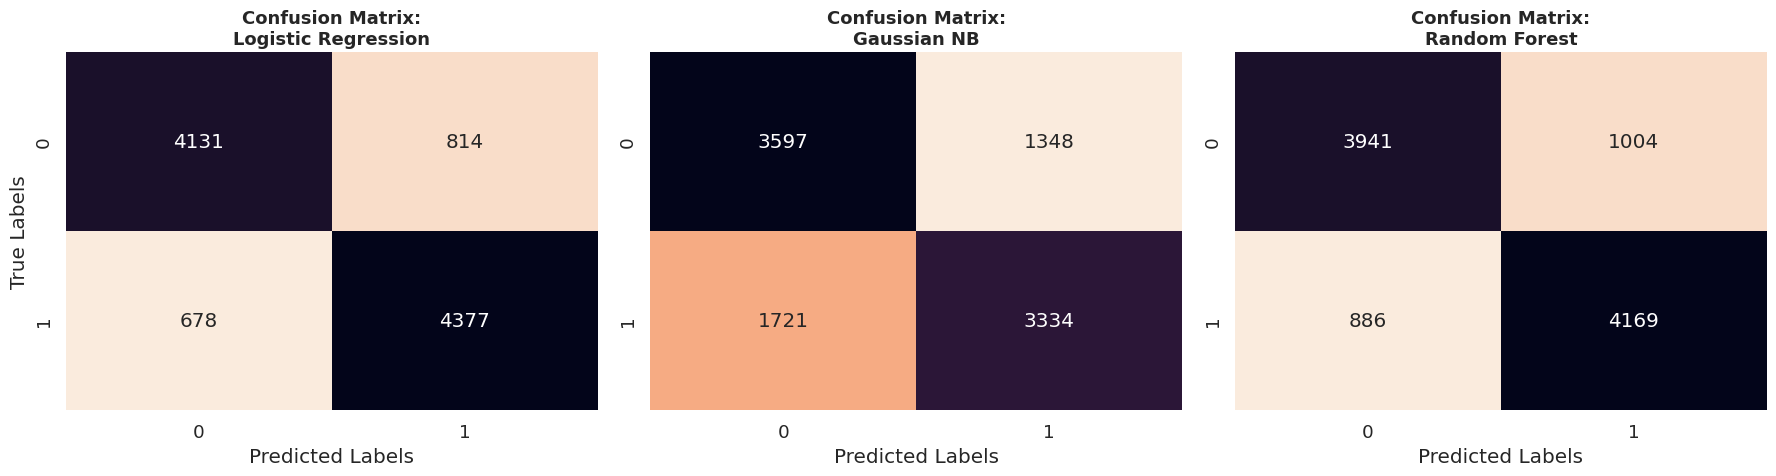

In [ ]:
from sklearn.metrics import confusion_matrix

# Setup a 1x3 grid for the 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

# Iterate through the trained Word2Vec models
for i, (name, model) in enumerate(w2v_models.items()):
    y_pred = model.predict(X_test_w2v)
    cm = confusion_matrix(y_test, y_pred)

    # Plotting the heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)

    axes[i].set_title(f'Confusion Matrix:\n{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted Labels')

    # Only show Y-label for the first plot to keep it clean
    if i == 0:
        axes[i].set_ylabel('True Labels')
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

# **LSTM Model Training**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# Parameters
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 100

# Tokenize text
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences so every input is the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

In [ ]:
# Define the LSTM Model
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Use 'softmax' and units=len(classes) if multi-class
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
start_train = time.time()
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)
train_time_lstm = time.time() - start_train

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1125/1125 ━━━━━━━━━━━━━━━━━━━━ 122s 104ms/step - accuracy: 0.7493 - loss: 0.4849 - val_accuracy: 0.8615 - val_loss: 0.3222
Epoch 2/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 119s 106ms/step - accuracy: 0.8947 - loss: 0.2640 - val_accuracy: 0.8687 - val_loss: 0.3062
Epoch 3/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 115s 102ms/step - accuracy: 0.9323 - loss: 0.1827 - val_accuracy: 0.8698 - val_loss: 0.3424
Epoch 4/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 142s 102ms/step - accuracy: 0.9569 - loss: 0.1200 - val_accuracy: 0.8470 - val_loss: 0.4401
Epoch 5/5
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 115s 102ms/step - accuracy: 0.9756 - loss: 0.0743 - val_accuracy: 0.8522 - val_loss: 0.5516


In [ ]:
import time
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)

# Timing Inference
start_test = time.time()
y_pred_probs = model.predict(X_test_pad).flatten() # Probabilities for ROC
y_pred_classes = (y_pred_probs > 0.5).astype(int)  # Binary classes for CM
test_time_lstm = time.time() - start_test

# Performance Metrics
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_classes),
    "Precision": precision_score(y_test, y_pred_classes, average='weighted'),
    "Recall": recall_score(y_test, y_pred_classes, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_classes, average='weighted'),
    "Train Time (s)": round(train_time_lstm, 4), # From previous training block
    "Test Time (s)": round(test_time_lstm, 4)
}

print("--- LSTM Performance Summary ---")
for k, v in metrics.items():
    print(f"{k}: {v}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step
--- LSTM Performance Summary ---
Accuracy: 0.8488
Precision: 0.8497457919916751
Recall: 0.8488
F1-Score: 0.8486426675662193
Train Time (s): 613.0232
Test Time (s): 10.3026


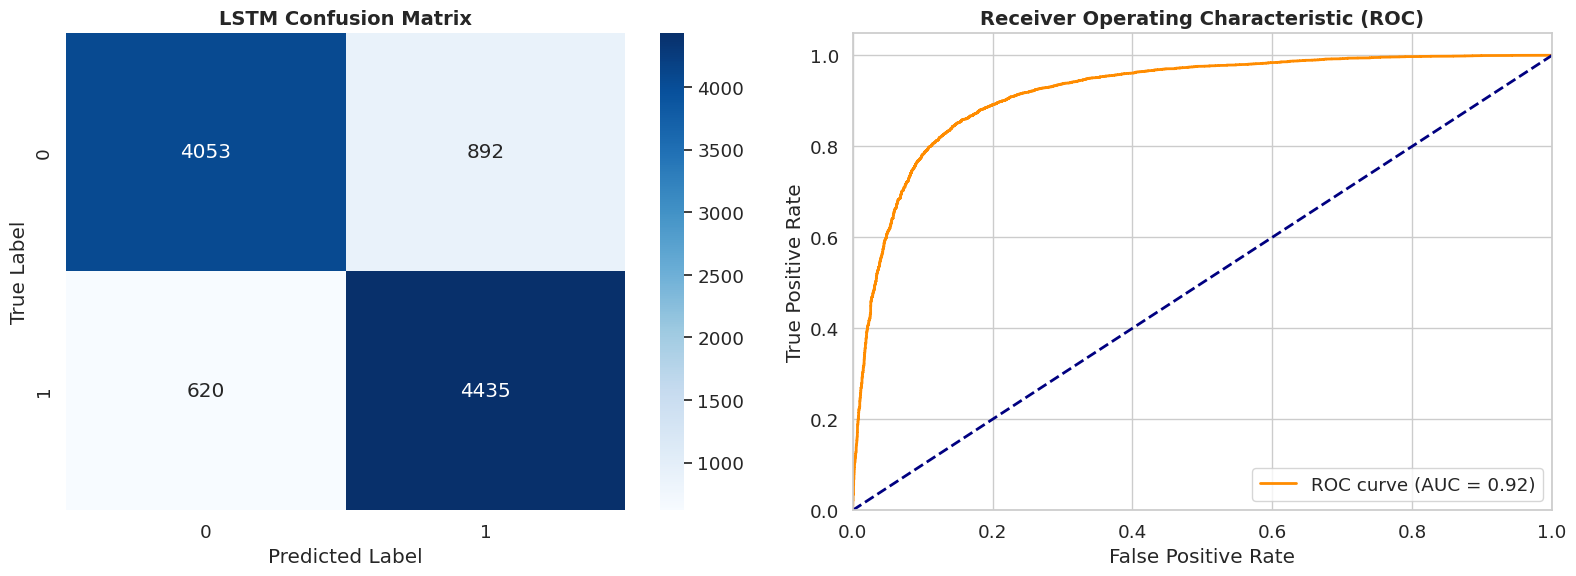

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
            xticklabels=le.classes_, yticklabels=le.classes_)
ax[0].set_title('LSTM Confusion Matrix', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# --- Plot 2: ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal line
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# **F1-Score Compairision of traditional model and LSTM**

In [ ]:
import numpy as np
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# 1. Faster Configuration
n_splits = 5  # Reduced from 10 to 5 for speed
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
baseline_scores = []
lstm_scores = []

# Move helper outside to save overhead
def build_lstm_model():
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
        Bidirectional(LSTM(32, return_sequences=False)), # Reduced units from 64 to 32
        Dropout(0.5),
        Dense(1, activation='sigmoid') # Simplified architecture
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print(f"Performing {n_splits}-fold Cross-Validation (Optimized for Speed)...")

for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    print(f"Processing Fold {i+1}/{n_splits}...")

    # Use .iloc for positional indexing on pandas Series (X_train)
    # Use direct indexing for numpy arrays (y_train)
    X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
    y_t, y_v = y_train[train_index], y_train[val_index]

    # --- Baseline ---
    X_t_tfidf = tfidf.transform(X_t)
    X_v_tfidf = tfidf.transform(X_v)
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_t_tfidf, y_t)
    baseline_scores.append(f1_score(y_v, lr.predict(X_v_tfidf), average='weighted'))

    # --- LSTM ---
    X_t_seq = pad_sequences(tokenizer.texts_to_sequences(X_t), maxlen=MAX_SEQUENCE_LENGTH)
    X_v_seq = pad_sequences(tokenizer.texts_to_sequences(X_v), maxlen=MAX_SEQUENCE_LENGTH)

    temp_lstm = build_lstm_model()
    # Reduced epochs to 2 for faster validation
    temp_lstm.fit(X_t_seq, y_t, epochs=2, batch_size=64, verbose=0)

    y_pred_lstm = (temp_lstm.predict(X_v_seq, verbose=0) > 0.5).astype(int)
    lstm_scores.append(f1_score(y_v, y_pred_lstm, average='weighted'))

# 2. Calculate Paired T-Test
t_stat, p_value = stats.ttest_rel(baseline_scores, lstm_scores)

# 3. Output Results (same logic as before)
print(f"\nMean Baseline F1: {np.mean(baseline_scores):.4f} | Mean LSTM F1: {np.mean(lstm_scores):.4f}")
print(f"P-value: {p_value:.4f}")

Performing 5-fold Cross-Validation (Optimized for Speed)...
Processing Fold 1/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Processing Fold 2/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Processing Fold 3/5...


...

Processing Fold 4/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Processing Fold 5/5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Mean Baseline F1: 0.8880 | Mean LSTM F1: 0.8533
P-value: 0.0015
